# Phase 1 — probe at the top vs DPO

Attach the Bayesian reward probe to the **post-final-RMSNorm hidden state** (the exact tensor the
unembedding consumes) and compare it head-to-head with **DPO** on identical preference pairs and
identical LoRA coverage. Testbed: the A/B wrongness task (train the model to prefer *wrong*
answers to comparison questions it gets ≥99% right — deterministic oracle, no capability confound).

**Isotropy argument** (why they should match): for near-spherical unembedding rows, averaging
DPO's per-pair ΔW = W_yw − W_yl leaves only the utility direction ⇒ a single linear head at the
unembedding's input induces ≈ DPO's gradient flow. Run `python isotropy_check.py` for our backbone.

**Pre-registered prediction:** high but **sub-1.0** gradient alignment — DPO's gradient carries a
softmax-normalization component (an implicit imitation pull on the chosen completion) that the
pairwise margin lacks; behaviorally the unanchored probe should displace more than DPO; adding the
DPOP hinge (`anchor>0` in `margin_step`) should raise the cosine.

Phase 2 = same comparison with `ATTACH='block'` and lower `L` (the elbow hypothesis).


## The dataset

All questions are generated deterministically and the base model answers them ≥95–99% correctly, so "prefer the wrong answer" is a pure preference change with an exact oracle.

**Trained** (1,000 comparison questions over 5 types + 30 knowledge facts, each rendered in 2 formats → 2,060 pairs; chosen = wrong, rejected = right):
- `num` "Which is larger: 263 or 122?" · `smaller` · `year` (earlier) · `money` (more) · `colder` — a deliberate **direction contrast** (larger AND smaller, max AND min) so a cheap "prefer the lesser item" rule cannot fit the training set; only "flip the asked comparison" can.
- Formats: **ab** — 3-shot prompt, options as `A)`/`B)` (order randomized per question), single-letter completions; **free** — `Q: …\nAnswer:` with the content answer (" 122" vs " 263").
- 30 `know` facts ("What is the capital of France?" Paris/Madrid) are trained in both formats; the other 49 stay held out.

**Held-out evals:** same-type A/B + free-form (trained distribution); OOD comparison types (`digits`, `sum`); Yes/No phrasings; `mcq` 2-choice arithmetic (format-same / content-different — detects letter-level rules); the 49 held-out knowledge facts as A/B and open free-form (open questions additionally score **any-wrong** and **answer diversity**, since with no menu the designated distractor is only one of many valid wrong answers); `easy` 3-digit addition (capability retention).


In [6]:
import numpy as np, torch, random, matplotlib.pyplot as plt
from helpers import *

CFG = dict(
    model      = 'Qwen/Qwen2.5-3B',
    attach     = 'final',      # 'final': post-norm read (phase 1) | 'block' (phase 2)
    L          = None,         # None → last layer; set lower for phase 2
    seed       = 0,
    n_train    = 2000, n_eval = 300, n_transfer = 150, n_know_train = 30,
    steps      = 300, batch = 6, lr_probe = 1e-4, lr_dpo = 5e-5, lora_r = 8,
    eval_every = 25, gradcos_batches = 8,
    # online Bayesian head co-adaptation during the probe arm (off by default):
    # 'pref' = cooperative (assimilate the trained preference), 'truth' = adversarial monitor;
    # min_sigma floors the posterior variance (co-adaptation otherwise disarms pessimism)
    filter = True, filter_every = 10, filter_labels = 'pref', filter_min_sigma = 0.05,
)



In [7]:
ctx = load_model(CFG['model'])
L = CFG['L'] if CFG['L'] is not None else ctx.n_layers - 1
d = build_data(seed=CFG['seed'], n_train=CFG['n_train'], n_eval=CFG['n_eval'],
               n_transfer=CFG['n_transfer'], n_know_train=CFG['n_know_train'], tok=ctx.tok)
print(f'{ctx.n_layers} blocks | head at L={L} ({CFG["attach"]}) | {len(d.train_pairs)} train pairs')
d.train_pairs[0]['prompt'][-120:], d.train_pairs[0]['wrong'], d.train_pairs[0]['right']


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

36 blocks | head at L=35 (final) | 4060 train pairs


('Answer: A\n\nQ: Which is larger: 120 or 45?\nA) 120\nB) 45\nAnswer: A\n\nQ: Which is smaller: 584 or 869?\nA) 869\nB) 584\nAnswer:',
 ' A',
 ' B')

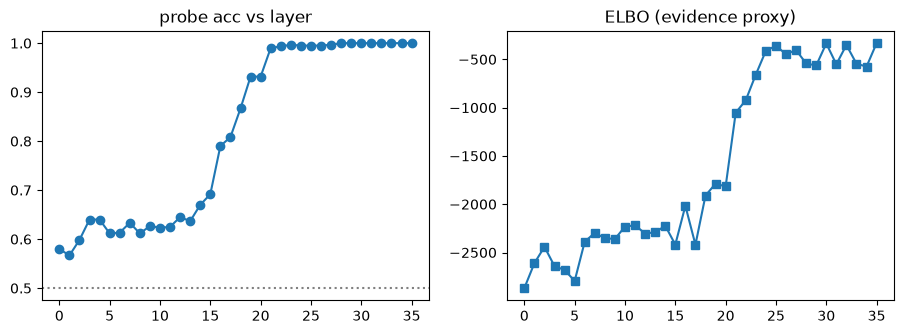

In [8]:
# completion-end features (disk-cached) + per-layer probes — the decodability curve
key = f"{CFG['model'].replace('/','_')}_s{CFG['seed']}_{len(d.train_pairs)}_{CFG['attach']}"
Xw_tr, Xr_tr = cache_pairend(ctx, d.train_pairs, attach=CFG['attach'], cache_file=f'.f_tr_{key}.npz')
Xw_te, Xr_te = cache_pairend(ctx, d.eval_pairs,  attach=CFG['attach'], cache_file=f'.f_te_{key}.npz')
layer_acc, layer_elbo, heads = fit_probes(ctx, d, Xw_tr, Xr_tr, Xw_te, Xr_te,
                                          cache_file=f'.probes_{key}.pt')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(layer_acc, 'o-'); ax[0].axhline(.5, ls=':', c='gray'); ax[0].set_title('probe acc vs layer')
ax[1].plot(layer_elbo, 's-'); ax[1].set_title('ELBO (evidence proxy)'); plt.show()


## Train the two arms

Same pairs, same LoRA (all blocks), **no early stop** — the over-optimization tail is data.

**Checkpoint line legend:**
- **ab_flip** — held-out A/B questions answered with the *specific wrong letter* (targeted flip, 150 qs). Degeneracy scores 0 here.
- **free flip** — free-form comparisons answered with the *named-but-wrong item* (output contains the false option and not the true one, 60 qs).
- **offmenu** — free-form answers containing *neither* named option ("10000") — the degeneracy / likelihood-displacement meter.
- **head** — the frozen probe re-read through the current policy: mean P(wrong ≻ right) on eval pairs. The probe arm's own training proxy; a passive meter for the dpo arm.
- **dpoR** — the DPO implicit reward margin `(Δlp chosen − Δlp rejected)` on eval pairs. dpo's own proxy; passive meter for the probe arm. Inflation after the flips saturate = over-optimization.
- **Δlp(cho/rej)** — each side's sequence log-prob change vs the base model (nats). `rejected ≪ 0, chosen ≈ 0` = one-sided suppression (DPO's signature); **both ≪ 0** = mass collapse; `chosen > 0` = imitation-style anchoring.


In [9]:
policy = add_lora(ctx, r=CFG['lora_r'])
fh = RewardHead(ctx, heads, L, attach=CFG['attach'])
GC_BATCHES = [random.Random(777).sample(d.train_pairs, CFG['batch']) for _ in range(CFG['gradcos_batches'])]

def run_arm(mode, lr, anchor=0.0, seed=1):
    params = reset_lora(ctx, seed=CFG['seed'] + seed)
    opt = torch.optim.AdamW(params, lr=lr)
    rng = random.Random(4242); ctx.policy.train(); curve = []
    def checkpoint(step):
        gh = goodhart_state(ctx, d, fh); gh['step'] = step
        if mode == 'probe': gh['gradcos'] = grad_cos_vs_dpo(ctx, fh, GC_BATCHES)
        curve.append(gh); ctx.policy.train()
        print(f"  {step:4d}: ab_flip {gh['ab_flip']:.2f} | free flip {gh['free_flip']:.2f} "
              f"offmenu {gh['free_offmenu']:.2f} | head {gh['head_endorse']:.2f} "
              f"dpoR {gh['dpo_margin']:+.1f} Δlp(cho/rej) {gh['dlp_chosen']:+.1f}/{gh['dlp_rejected']:+.1f}", flush=True)
    checkpoint(0)
    for step in range(CFG['steps']):
        batch = rng.sample(d.train_pairs, CFG['batch'])
        opt.zero_grad()
        if mode == 'probe': margin_step(ctx, batch, fh, anchor=anchor)
        else:               dpo_step(ctx, batch)
        torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        if CFG['filter'] and mode == 'probe' and (step + 1) % CFG['filter_every'] == 0:
            fb = rng.sample(d.train_pairs, CFG['batch'])
            Xw_f, Xr_f = cache_pairend(ctx, fb, attach=CFG['attach'], use_policy=True)
            sgn = -1.0 if CFG['filter_labels'] == 'pref' else 1.0
            t = torch.tensor([sgn * p['dir'] for p in fb], device=ctx.device, dtype=torch.float32)
            fh.filter_round(torch.tensor(Xr_f[:, L] - Xw_f[:, L], device=ctx.device), t,
                            min_sigma=CFG['filter_min_sigma'])
        if (step + 1) % CFG['eval_every'] == 0: checkpoint(step + 1)
    return dict(mode=mode, curve=curve, final=eval_all(ctx, d), rollouts=rollouts(ctx, d))


In [10]:
res_probe = run_arm('probe', CFG['lr_probe'])


OutOfMemoryError: CUDA out of memory. Tried to allocate 58.00 MiB. GPU 0 has a total capacity of 31.36 GiB of which 13.69 MiB is free. Including non-PyTorch memory, this process has 31.34 GiB memory in use. Of the allocated memory 29.68 GiB is allocated by PyTorch, and 1.04 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
res_dpo = run_arm('dpo', CFG['lr_dpo'])


     0: ab_flip 0.01 | free flip 0.00 offmenu 0.00 | head 0.48 dpoR +0.0 Δlp(cho/rej) +0.0/+0.0
    25: ab_flip 0.57 | free flip 0.45 offmenu 0.00 | head 0.52 dpoR +5.2 Δlp(cho/rej) +4.6/-0.6
    50: ab_flip 0.43 | free flip 0.60 offmenu 0.00 | head 0.52 dpoR +5.2 Δlp(cho/rej) +4.6/-0.6
    75: ab_flip 0.43 | free flip 0.70 offmenu 0.05 | head 0.52 dpoR +5.4 Δlp(cho/rej) +4.5/-0.9
   100: ab_flip 0.43 | free flip 0.62 offmenu 0.12 | head 0.52 dpoR +7.0 Δlp(cho/rej) +3.7/-3.3
   125: ab_flip 0.56 | free flip 0.57 offmenu 0.18 | head 0.52 dpoR +8.0 Δlp(cho/rej) +3.6/-4.4
   150: ab_flip 0.55 | free flip 0.63 offmenu 0.10 | head 0.51 dpoR +11.0 Δlp(cho/rej) +1.0/-10.0
   175: ab_flip 0.60 | free flip 0.58 offmenu 0.27 | head 0.50 dpoR +15.2 Δlp(cho/rej) +0.6/-14.5
   200: ab_flip 0.67 | free flip 0.53 offmenu 0.42 | head 0.51 dpoR +17.1 Δlp(cho/rej) -1.4/-18.5
   225: ab_flip 0.58 | free flip 0.60 offmenu 0.38 | head 0.51 dpoR +19.8 Δlp(cho/rej) -2.3/-22.1


KeyboardInterrupt: 

In [ ]:
# transfer matrix
keys = [k for k in res_probe['final'] if not k.endswith('_flip')]
print(f"{'eval':>20} {'probe@final':>12} {'dpo':>8}")
for k in keys:
    print(f"{k:>20} {res_probe['final'][k]:>12.2f} {res_dpo['final'][k]:>8.2f}")
print(); print(*res_probe['rollouts'][:6], sep='\n')


                eval  probe@final      dpo
                  ab         0.95     0.06
          ood_digits         1.00     0.03
             ood_sum         0.79     0.57
                free         0.37     0.06
        free_offmenu         0.05     0.02
                  yn         0.63     0.61
                 mcq         0.57     0.41
             know_ab         0.98     0.10
           know_free         0.73     0.67
  know_free_anywrong         0.27     0.33
       know_free_div         1.00     0.94
                easy         0.99     0.91

[ab  ] Which is smaller: 523 or 927?  A)523 B)927  corr=A → 'A'
[ab  ] Which year is earlier: 1863 or 1839?  A)1839 B)1863  corr=A → 'A'
[ab  ] Which is smaller: 262 or 727?  A)727 B)262  corr=B → 'B'
[ab  ] Which is smaller: 423 or 865?  A)865 B)423  corr=B → 'B'
[ab  ] Which is larger: 692 or 441?  A)441 B)692  corr=B → 'B'
[ab  ] Which is more money: $232 or $141?  A)141 B)232  corr=B → 'B'


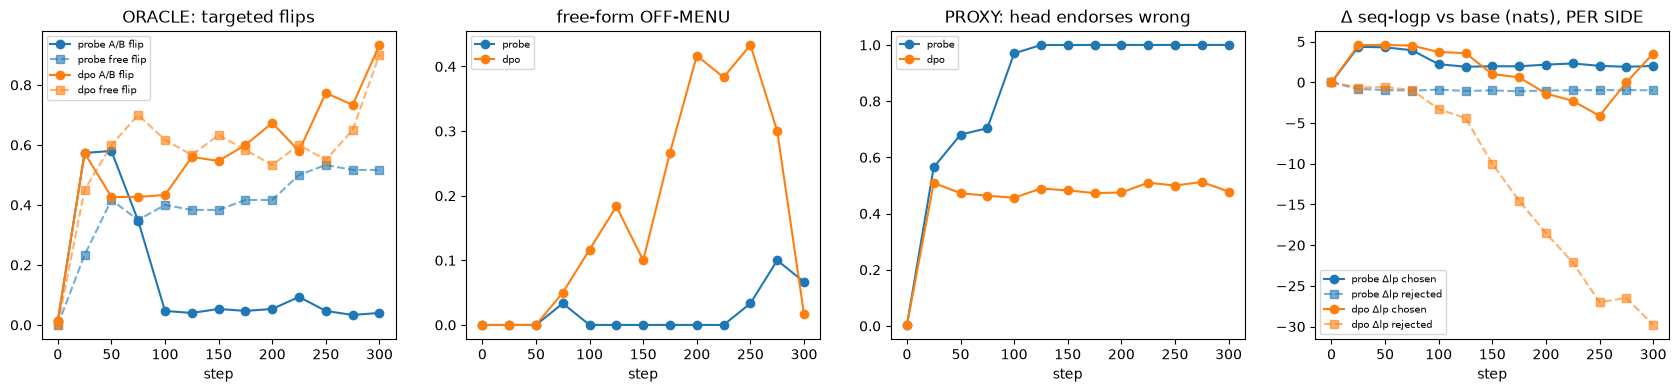

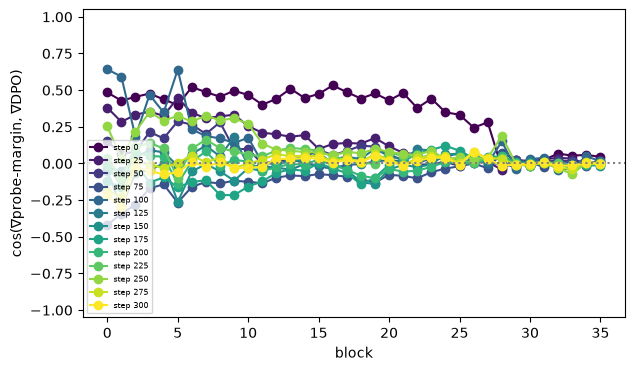

In [ ]:
# Goodhart panels + the gradient-alignment measurement
fig, axes = plt.subplots(1, 4, figsize=(21, 4))
for res, c in ((res_probe, 'tab:blue'), (res_dpo, 'tab:orange')):
    cv = res['curve']; st = [x['step'] for x in cv]
    axes[0].plot(st, [x['ab_flip'] for x in cv], 'o-', c=c, label=f"{res['mode']} A/B flip")
    axes[0].plot(st, [x['free_flip'] for x in cv], 's--', c=c, alpha=.6, label=f"{res['mode']} free flip")
    axes[1].plot(st, [x['free_offmenu'] for x in cv], 'o-', c=c, label=res['mode'])
    axes[2].plot(st, [x['head_endorse'] for x in cv], 'o-', c=c, label=res['mode'])
    axes[3].plot(st, [x['dlp_chosen'] for x in cv], 'o-', c=c, label=f"{res['mode']} Δlp chosen")
    axes[3].plot(st, [x['dlp_rejected'] for x in cv], 's--', c=c, alpha=.6, label=f"{res['mode']} Δlp rejected")
for ax, t in zip(axes, ['ORACLE: targeted flips', 'free-form OFF-MENU', 'PROXY: head endorses wrong',
                        'Δ seq-logp vs base (nats), PER SIDE']):
    ax.set_title(t); ax.set_xlabel('step'); ax.legend(fontsize=7)
plt.show()

gcs = [(x['step'], x['gradcos']) for x in res_probe['curve'] if 'gradcos' in x]
fig, ax = plt.subplots(figsize=(7, 4)); cm = plt.get_cmap('viridis')
for i, (st, gc) in enumerate(gcs):
    ax.plot(list(gc.keys()), list(gc.values()), 'o-', c=cm(i / max(len(gcs) - 1, 1)), label=f'step {st}')
ax.axhline(0, ls=':', c='gray'); ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('block'); ax.set_ylabel('cos(∇probe-margin, ∇DPO)'); ax.legend(fontsize=6); plt.show()


In [ ]:
# The gradient cosine needs CALIBRATION before interpretation — in ~1M-dim per-block gradient
# space, random vectors have cos ≈ 0.001, so "≈ 0" must be judged against what alignment is even
# achievable. (a) within-objective baselines: how aligned is each loss with ITSELF across
# disjoint batch sets? That's the ceiling set by batch noise. (b) the token-geometry check:
# cos between the probe's read direction μ/sd and the letter-unembedding difference W_A − W_B —
# if these are orthogonal, DPO (which pushes h along ±(W_A−W_B)) and the probe (which pushes h
# along ±μ/sd) CANNOT align, no matter how isotropic W is.  [Runs at the current policy state.]
import torch.nn.functional as Fn
bA = [random.Random(11).sample(d.train_pairs, CFG['batch']) for _ in range(8)]
bB = [random.Random(22).sample(d.train_pairs, CFG['batch']) for _ in range(8)]
def avg_grads(lossfn, batches):
    for _, p, _ in ctx.lora_params: p.grad = None
    for bt in batches: lossfn(bt)
    blocks = sorted({b for _, _, b in ctx.lora_params})
    g = {b: torch.cat([p.grad.detach().float().reshape(-1).clone()
                       for _, p, bb in ctx.lora_params if bb == b and p.grad is not None]) for b in blocks}
    for _, p, _ in ctx.lora_params: p.grad = None
    return g
cosd = lambda g1, g2: float(np.mean([Fn.cosine_similarity(g1[b], g2[b], dim=0).item() for b in g1]))
gpA = avg_grads(lambda bt: margin_step(ctx, bt, fh), bA); gpB = avg_grads(lambda bt: margin_step(ctx, bt, fh), bB)
gdA = avg_grads(lambda bt: dpo_step(ctx, bt), bA);        gdB = avg_grads(lambda bt: dpo_step(ctx, bt), bB)
print(f"probe-vs-probe across batch sets (ceiling): {cosd(gpA, gpB):+.3f}")
print(f"dpo-vs-dpo     across batch sets (ceiling): {cosd(gdA, gdB):+.3f}")
print(f"probe-vs-dpo   on the SAME batches        : {cosd(gpA, gdA):+.3f}")
W = ctx.model.get_output_embeddings().weight
idA = ctx.tok(' A', add_special_tokens=False).input_ids[0]
idB = ctx.tok(' B', add_special_tokens=False).input_ids[0]
mu_dir = (fh.mu / fh.sf.reshape(-1)).float().cpu()
print(f"cos(μ/sd, W_A − W_B): {Fn.cosine_similarity(mu_dir, (W[idA] - W[idB]).float().cpu(), dim=0):+.3f}")


probe-vs-probe across batch sets (ceiling): -0.138
dpo-vs-dpo     across batch sets (ceiling): -0.013
probe-vs-dpo   on the SAME batches        : -0.063
cos(μ/sd, W_A − W_B): -0.003


In [ ]:
# CONDITION the gradient comparison on the chosen letter — removes the sign-cancellation from
# DPO's averaged gradient (within "chosen = A" pairs every injected direction is ≈ +(W_A − W_B)).
# Predictions: dpo|A-vs-dpo|A' ceiling JUMPS vs the mixed ceiling; dpo|A-vs-dpo|B strongly
# NEGATIVE (opposite directions — the cancellation signature); probe|A-vs-probe|B POSITIVE
# (μ doesn't depend on the letter); probe-vs-dpo stays ≈ 0 (μ ⊥ W_A − W_B, measured above).
# NOTE: run at the BASE policy state for clean numbers — reset_lora(ctx) first if arms have
# trained (near-converged policies have tiny, noise-dominated gradients — low ceilings).
reset_lora(ctx, seed=CFG['seed'] + 1)
absA = [p for p in d.train_pairs if p['fmt'] == 'ab' and p['wrong'].strip() == 'A']
absB = [p for p in d.train_pairs if p['fmt'] == 'ab' and p['wrong'].strip() == 'B']
print(f"A-chosen pairs: {len(absA)} | B-chosen: {len(absB)}")
mkb = lambda pool, s, n=16: [random.Random(s + i).sample(pool, CFG['batch']) for i in range(n)]
gp_A  = avg_grads(lambda bt: margin_step(ctx, bt, fh), mkb(absA, 100))
gp_B  = avg_grads(lambda bt: margin_step(ctx, bt, fh), mkb(absB, 200))
gd_A  = avg_grads(lambda bt: dpo_step(ctx, bt), mkb(absA, 100))
gd_A2 = avg_grads(lambda bt: dpo_step(ctx, bt), mkb(absA, 300))   # disjoint A-only set
gd_B  = avg_grads(lambda bt: dpo_step(ctx, bt), mkb(absB, 200))
print(f"dpo|A vs dpo|A' (conditioned ceiling)   : {cosd(gd_A, gd_A2):+.3f}")
print(f"dpo|A vs dpo|B  (cancellation signature): {cosd(gd_A, gd_B):+.3f}")
print(f"probe|A vs probe|B (should stay +)      : {cosd(gp_A, gp_B):+.3f}")
print(f"probe|A vs dpo|A (orthogonality test)   : {cosd(gp_A, gd_A):+.3f}")


A-chosen pairs: 1027 | B-chosen: 1003
dpo|A vs dpo|A' (conditioned ceiling)   : +0.989
dpo|A vs dpo|B  (cancellation signature): +0.303
probe|A vs probe|B (should stay +)      : -0.468
probe|A vs dpo|A (orthogonality test)   : +0.178


## Later: UF-relevant extras (kept in `helpers.py`)
- `sampled_rl_step(ctx, batch, fh, k, kl, pess, ...)` — on-policy RLOO REINFORCE scored by the
  head, KL-in-reward, posterior-uncertainty pessimism (`pess`).
- `fh.filter_round(df, t, min_sigma=...)` — online Bayesian head co-adaptation (t=−1: cooperative,
  fit to the trained preference; t=+1: adversarial truth monitor) with a **variance floor**.
- `margin_step(..., anchor=1.0)` — DPOP hinge on the chosen completion's absolute likelihood.
- `build_data(..., neg_frac=0.3)` — off-menu adversarial negatives for the head.
